# Walkthrough of `tests/test_pipeline.py`

This notebook reproduces the end-to-end checks from the test file step by step, with plots at each stage so you can visualize what each part of the pipeline is doing.

1. `Q_000(s)` from pair counts vs the analytic self-overlap volume of a sphere.
2. The monopole covariance vs a brute-force evaluation for an isotropic `P(k)`.
3. A far-away sphere (distant observer): ratios `C_{l1 l2}/C_00` close to the periodic-box values.

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, eval_legendre

from pkcov import Tracer, PowerSpectrumModel, GaussianCovariance
from pkcov.tracers import Window
from pkcov.windows import TripolarWindow
from pkcov.wigner import FOUR_PI

## Helper functions

Same helpers used by the tests: synthetic randoms in a sphere, a smooth isotropic `P(k)` model, a brute-force monopole covariance, and a 4-Legendre integral used for the box-multipole ratios.

In [2]:
def sphere_randoms(R, n, center=(0.0, 0.0, 0.0), nbar=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    pts = []
    while sum(len(p) for p in pts) < n:
        x = rng.uniform(-R, R, size=(2 * n, 3))
        pts.append(x[np.sum(x * x, axis=1) < R * R])
    pos = np.concatenate(pts)[:n] + np.asarray(center)
    V = 4 * np.pi / 3 * R ** 3
    alpha = nbar * V / n
    return {'POSITION': pos, 'WEIGHT': np.ones(n), 'NZ': np.full(n, nbar)}, alpha


def pk_model():
    k = np.geomspace(1e-3, 1.0, 400)
    P0 = 2e4 * (k / 0.05) / (1 + (k / 0.05) ** 2.2)     # smooth, isotropic
    return k, P0


def bruteforce_monopole(R, k_edges, kfun, nq=24):
    """2/I^2 * <P P |W~(k1-k2)|^2> over shells, for a top-hat sphere of radius R."""
    I = 4 * np.pi / 3 * R ** 3                                # per nbar^2 (nbar cancels)
    q = np.linspace(1e-6, 2 * k_edges[-1] + 0.05, 200001)
    wt = 4 * np.pi * R ** 3 * spherical_jn(1, q * R) / (q * R)
    cum = np.concatenate([[0.0], np.cumsum(0.5 * (q[1:] * wt[1:] ** 2 + q[:-1] * wt[:-1] ** 2) * np.diff(q))])
    G = lambda x: np.interp(x, q, cum)
    x, wgl = np.polynomial.legendre.leggauss(nq)
    nb = len(k_edges) - 1
    C = np.zeros((nb, nb))
    for i in range(nb):
        k1 = 0.5 * (k_edges[i + 1] - k_edges[i]) * x + 0.5 * (k_edges[i + 1] + k_edges[i])
        w1 = 0.5 * (k_edges[i + 1] - k_edges[i]) * wgl * k1 ** 2 * kfun(k1)
        n1 = (k_edges[i + 1] ** 3 - k_edges[i] ** 3) / 3
        for j in range(nb):
            k2 = 0.5 * (k_edges[j + 1] - k_edges[j]) * x + 0.5 * (k_edges[j + 1] + k_edges[j])
            w2 = 0.5 * (k_edges[j + 1] - k_edges[j]) * wgl * k2 ** 2 * kfun(k2)
            n2 = (k_edges[j + 1] ** 3 - k_edges[j] ** 3) / 3
            K1, K2 = k1[:, None], k2[None, :]
            F = (G(K1 + K2) - G(np.abs(K1 - K2))) / (2 * K1 * K2)      # int dmu/2 |W~|^2
            C[i, j] = 2.0 / I ** 2 * np.sum(w1[:, None] * w2[None, :] * F) / (n1 * n2)
    return C


def _legendre4(l1, l2, L1, L2):
    x, w = np.polynomial.legendre.leggauss(40)
    return 0.5 * np.sum(w * eval_legendre(l1, x) * eval_legendre(l2, x) * eval_legendre(L1, x) * eval_legendre(L2, x))

## Test 1 — `Q_000(s)` for a sphere of randoms

### Step 1: build the randoms and the tracer/window

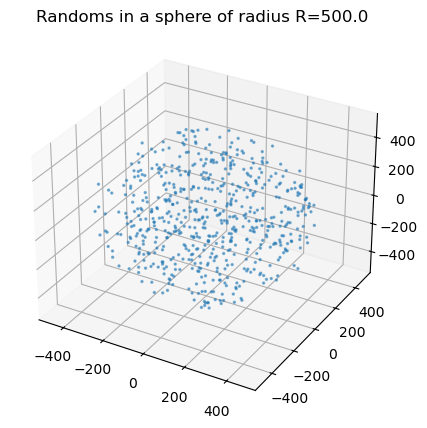

In [3]:
R, n, nbar = 500.0, 12000, 2e-4
rnd, alpha = sphere_randoms(R, n, nbar=nbar)
tr = Tracer('T', rnd, alpha)
w = Window('W', tr, tr)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': '3d'})
sub = rnd['POSITION'][::20]
ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=2, alpha=0.5)
ax.set_title(f'Randoms in a sphere of radius R={R}')
plt.show()

### Step 2: compute the tripolar window (pair counts) and compare `Q_000` to the analytic self-overlap volume

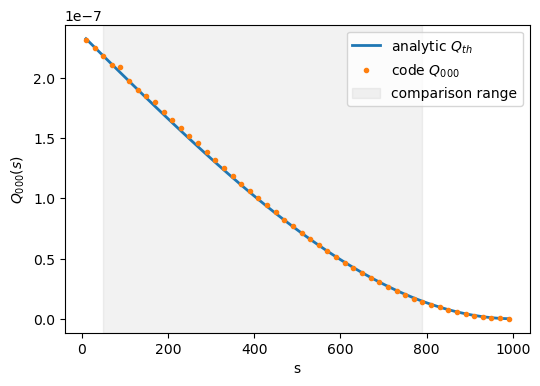

max rel. diff in comparison range: 0.028529257575583444


In [4]:
s_edges = np.arange(0, 2 * R + 20, 20.0)
tw = TripolarWindow(w, w, [(0, 0, 0), (0, 0, 2)], s_edges, n_sub=3000).compute()
s = tw.s_centers
Vov = np.pi / 12 * (4 * R + s) * (2 * R - s) ** 2
Q_th = FOUR_PI ** (-1.5) * FOUR_PI * nbar ** 4 * Vov
sel = (s > 40) & (s < 1.6 * R)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s, Q_th, label='analytic $Q_{th}$', lw=2)
ax.plot(s, tw.Q[(0, 0, 0)], 'o', ms=3, label='code $Q_{000}$')
ax.axvspan(s[sel][0], s[sel][-1], color='gray', alpha=0.1, label='comparison range')
ax.set_xlabel('s')
ax.set_ylabel('$Q_{000}(s)$')
ax.legend()
plt.show()

print('max rel. diff in comparison range:', np.max(np.abs(tw.Q[(0, 0, 0)][sel] / Q_th[sel] - 1)))

### Step 3: check isotropy — the `(0,0,2)` s-quadrupole of an origin-centred sphere should vanish

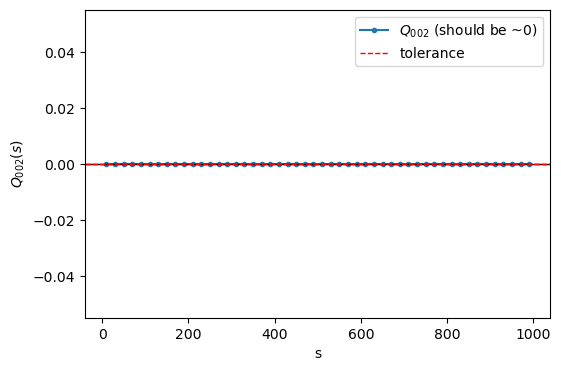

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s, tw.Q[(0, 0, 2)], 'o-', ms=3, label='$Q_{002}$ (should be ~0)')
ax.axhline(0, color='k', lw=1)
ax.axhline(0.03 * np.max(np.abs(Q_th[sel])), color='r', ls='--', lw=1, label='tolerance')
ax.axhline(-0.03 * np.max(np.abs(Q_th[sel])), color='r', ls='--', lw=1)
ax.set_xlabel('s')
ax.set_ylabel('$Q_{002}(s)$')
ax.legend()
plt.show()

## Test 2 — monopole covariance vs brute force

### Step 1: set up the tracer, the power spectrum model, and the k-bins

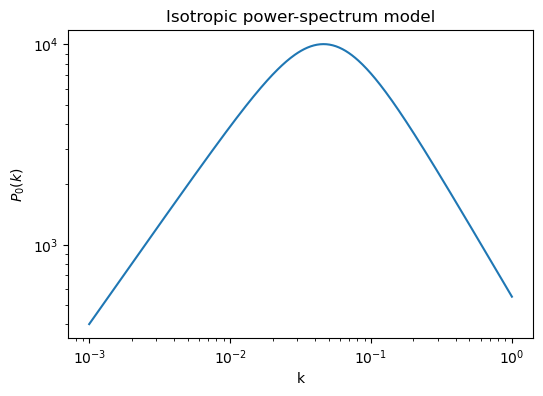

k_edges: [0.02 0.04 0.06 0.08 0.1  0.12]


In [6]:
R, n, nbar = 500.0, 12000, 2e-4
rnd, alpha = sphere_randoms(R, n, nbar=nbar)
tr = Tracer('T', rnd, alpha)
k, P0 = pk_model()

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(k, P0)
ax.set_xlabel('k')
ax.set_ylabel('$P_0(k)$')
ax.set_title('Isotropic power-spectrum model')
plt.show()

model = PowerSpectrumModel()
model.add(('T', 'T'), {0: (k, P0)})
k_edges = np.arange(0.02, 0.13, 0.02)
print('k_edges:', k_edges)

### Step 2: compute the windowed Gaussian covariance

In [7]:
cov = GaussianCovariance([tr], k_edges, ells=(0,), L_max=0, s_max=2 * R, ds=2.0, ds_pair=10.0,
                         shot_noise=False, n_sub=3000)
cov.compute_windows([('T', 'T')]).set_model(model)
C = cov.block(('T', 'T'), ('T', 'T'), 0, 0)
C

array([[2.69770673e+05, 1.86027159e+04, 1.07544424e+03, 2.44477128e+02,
        5.12536238e+01],
       [1.86027159e+04, 1.18286401e+05, 7.72908940e+03, 2.37067886e+02,
        1.39947993e+02],
       [1.07544424e+03, 7.72908940e+03, 4.98056024e+04, 3.29852552e+03,
        2.00540442e+02],
       [2.44477128e+02, 2.37067886e+02, 3.29852552e+03, 2.24182708e+04,
        1.54743271e+03],
       [5.12536238e+01, 1.39947993e+02, 2.00540442e+02, 1.54743271e+03,
        1.09214827e+04]])

### Step 3: compute the brute-force reference covariance and compare

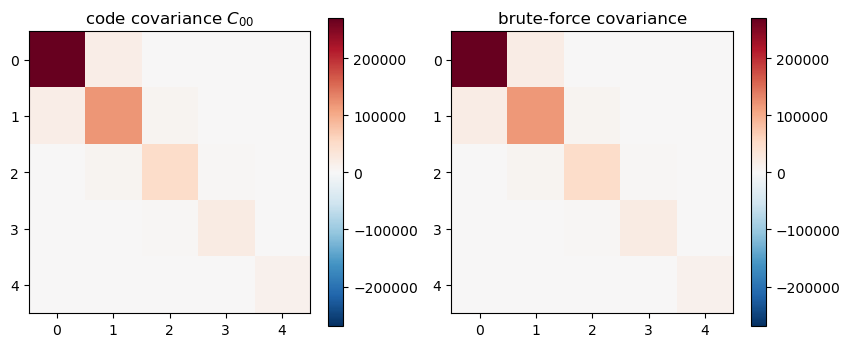

In [8]:
Cb = bruteforce_monopole(R, k_edges, lambda kk: np.interp(kk, k, P0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = np.max(np.abs(C))
im0 = axes[0].imshow(C, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('code covariance $C_{00}$')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(Cb, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('brute-force covariance')
plt.colorbar(im1, ax=axes[1])
plt.show()

### Step 4: check the diagonal and first off-diagonal agreement

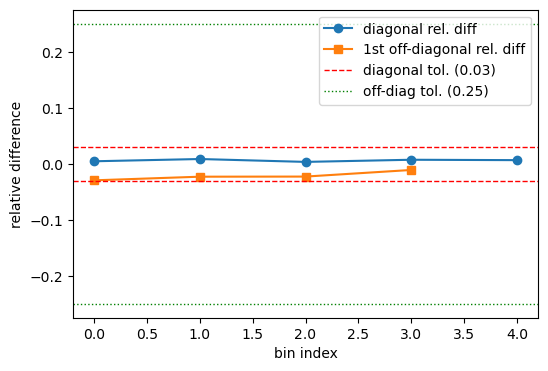

diagonal rel. diff: [0.00437557 0.008399   0.00326444 0.00708817 0.00638812]
off-diagonal rel. diff: [-0.02965461 -0.02316464 -0.02295791 -0.01115846]


In [9]:
d = np.diag(C) / np.diag(Cb) - 1
o = np.diag(C, 1) / np.diag(Cb, 1) - 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d, 'o-', label='diagonal rel. diff')
ax.plot(o, 's-', label='1st off-diagonal rel. diff')
ax.axhline(0.03, color='r', ls='--', lw=1, label='diagonal tol. (0.03)')
ax.axhline(-0.03, color='r', ls='--', lw=1)
ax.axhline(0.25, color='g', ls=':', lw=1, label='off-diag tol. (0.25)')
ax.axhline(-0.25, color='g', ls=':', lw=1)
ax.set_xlabel('bin index')
ax.set_ylabel('relative difference')
ax.legend()
plt.show()

print('diagonal rel. diff:', d)
print('off-diagonal rel. diff:', o)

## Test 3 — far-away sphere: multipole ratios approach the periodic-box values

### Step 1: place the sphere far from the observer and build the Kaiser multipoles

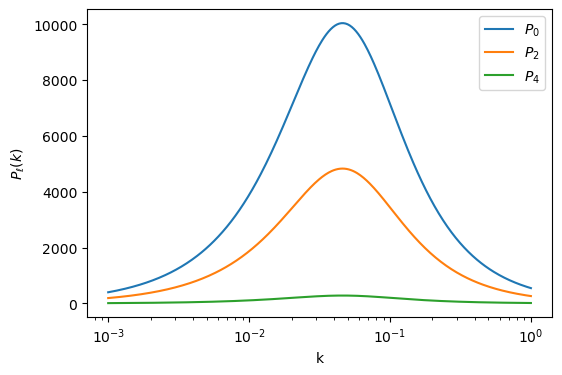

In [10]:
R, n, nbar = 500.0, 12000, 2e-4
rnd, alpha = sphere_randoms(R, n, center=(0, 0, 40000.0), nbar=nbar)
tr = Tracer('T', rnd, alpha)
k, P0 = pk_model()
f, b = 0.8, 2.0
beta = f / b
# Kaiser multipoles
P2 = P0 * (4 * beta / 3 + 4 * beta ** 2 / 7) / (1 + 2 * beta / 3 + beta ** 2 / 5)
P4 = P0 * (8 * beta ** 2 / 35) / (1 + 2 * beta / 3 + beta ** 2 / 5)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(k, P0, label='$P_0$')
ax.semilogx(k, P2, label='$P_2$')
ax.semilogx(k, P4, label='$P_4$')
ax.set_xlabel('k')
ax.set_ylabel('$P_\\ell(k)$')
ax.legend()
plt.show()

### Step 2: compute the covariance for `ells=(0,2,4)`

In [11]:
model = PowerSpectrumModel()
model.add(('T', 'T'), {0: (k, P0), 2: (k, P2), 4: (k, P4)})
k_edges = np.array([0.06, 0.08, 0.10])
cov = GaussianCovariance([tr], k_edges, ells=(0, 2, 4), L_max=4, s_max=2 * R, ds=2.0, ds_pair=10.0,
                         shot_noise=False, n_sub=2500)
cov.compute_windows([('T', 'T')]).set_model(model)
kc = 0.5 * (k_edges[:-1] + k_edges[1:])
PL = {0: np.interp(kc, k, P0), 2: np.interp(kc, k, P2), 4: np.interp(kc, k, P4)}
C = {(l1, l2): cov.block(('T', 'T'), ('T', 'T'), l1, l2) for l1 in (0, 2, 4) for l2 in (0, 2, 4)}
print('computed blocks:', list(C.keys()))

computed blocks: [(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4)]


### Step 3: compare code ratios `C_{l1 l2}/C_00` to the periodic-box expectation, and check exchange symmetry

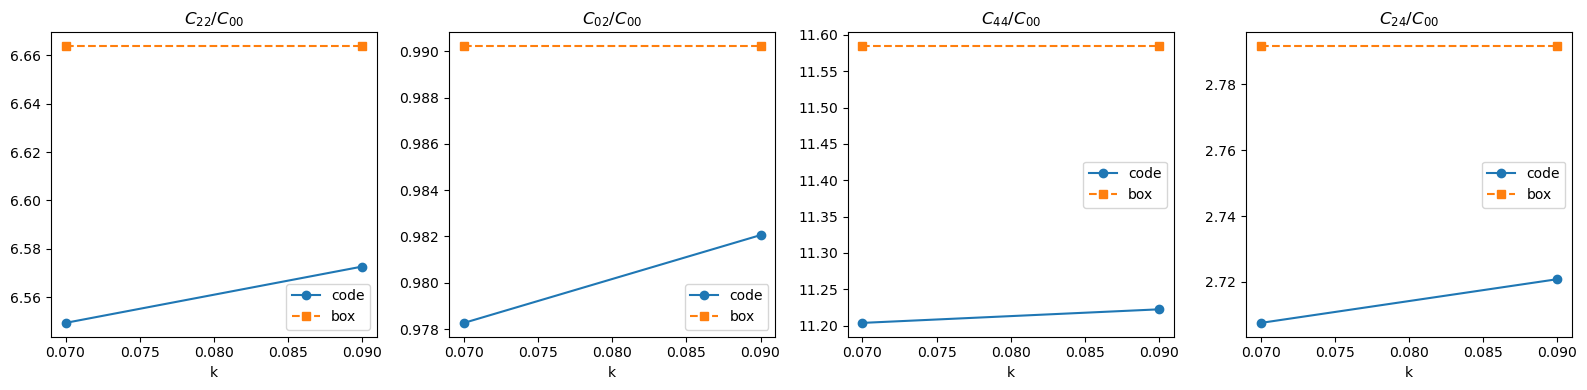

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
pairs = [(2, 2), (0, 2), (4, 4), (2, 4)]
for ax, (l1, l2) in zip(axes, pairs):
    box = (2 * l1 + 1) * (2 * l2 + 1) * sum(PL[L1] * PL[L2] * _legendre4(l1, l2, L1, L2)
                                            for L1 in (0, 2, 4) for L2 in (0, 2, 4))
    box00 = sum(PL[L1] * PL[L2] * _legendre4(0, 0, L1, L2) for L1 in (0, 2, 4) for L2 in (0, 2, 4))
    ratio_code = np.diag(C[(l1, l2)]) / np.diag(C[(0, 0)])
    ratio_box = box / box00
    ax.plot(kc, ratio_code, 'o-', label='code')
    ax.plot(kc, ratio_box, 's--', label='box')
    ax.set_title(f'$C_{{{l1}{l2}}}/C_{{00}}$')
    ax.set_xlabel('k')
    ax.legend()
plt.tight_layout()
plt.show()

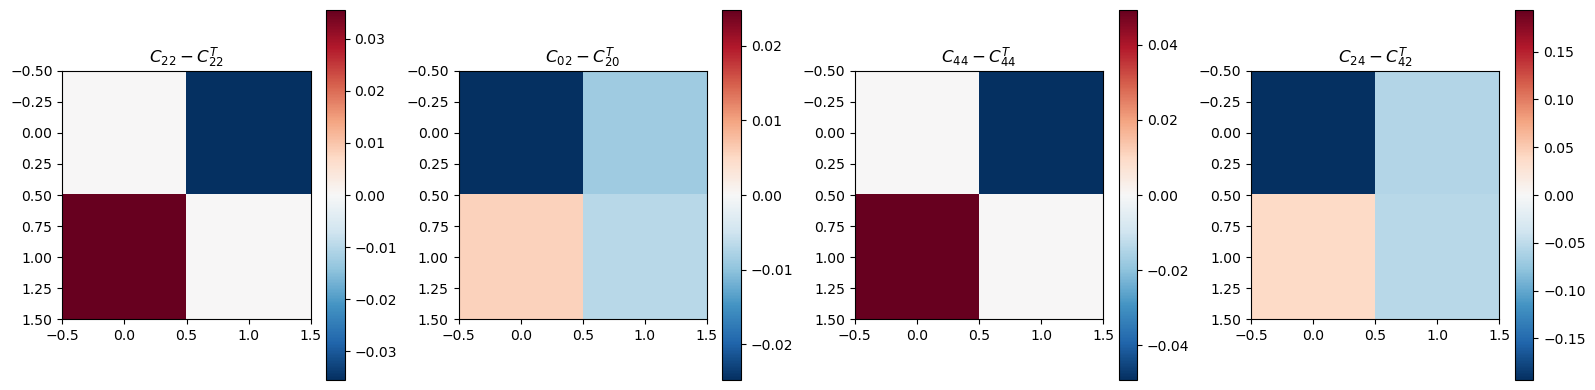

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (l1, l2) in zip(axes, pairs):
    asym = C[(l1, l2)] - C[(l2, l1)].T
    vmax = max(1e-12, np.max(np.abs(asym)))
    im = ax.imshow(asym, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'$C_{{{l1}{l2}}} - C_{{{l2}{l1}}}^T$')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Cubic box test (periodic-box limit)

Based on the "Box test" in `thecov2.ipynb`: place a small cubic random catalogue far from the observer (plane-parallel limit) with a *flat* monopole `P0` plus shot noise, and compare the code's diagonal covariance against the standard periodic-box Gaussian formula

$$C_{00}(k,k) = \frac{2\left(P_0 + 1/\bar n\right)^2}{N_\text{modes}(k)}, \qquad N_\text{modes}(k) = \frac{V}{6\pi^2}\left(k_\text{hi}^3 - k_\text{lo}^3\right).$$

Note the box here is a genuine finite (non-periodic) point set, so this is only an approximate cross-check (unlike the periodic-box FFT used by `thecov2.ipynb`); the parameters below are tuned to the shot-noise-dominated regime where the two agree well.

In [14]:

from tests.test_box import analytic_box, leakage_fractions

boxsize = 4e3
nrandoms = 2000000
alpha = 1.0
distance = 0.0
P0_flat = 1e4
kmin, kmax, dk = 0.0, 0.4, 0.01
ellmax = 2

rng = np.random.default_rng(0)
positions = rng.uniform(-boxsize / 2, boxsize / 2, size=(nrandoms, 3))
positions[:, 0] += distance
nbar = alpha * nrandoms / boxsize ** 3
randoms = {'POSITION': positions, 'WEIGHT': np.ones(nrandoms), 'NZ': np.full(nrandoms, nbar)}
tracer = Tracer('A', randoms, alpha=alpha)

k_edges = np.arange(kmin, kmax + dk / 2, dk)
kk = np.linspace(0.0, 1.0, 50)
model = PowerSpectrumModel()
model.add(('A', 'A'), {0: (kk, np.full_like(kk, P0_flat))})     # P2 = P4 = 0


In [15]:
import time
ells = tuple(range(0, ellmax + 1, 2))
t0 = time.time()
cov = GaussianCovariance([tracer], k_edges, ells=ells, L_max=ellmax, ds=2.0, ds_pair=10.0,
                         shot_noise=True, n_sub=5000, n_near=200000, s_split=80.0)
cov.compute_windows([('A', 'A')])
print(f"window functions: {time.time() - t0:.1f} s")
cov.set_model(model)
block = {(l1, l2): cov.block(('A', 'A'), ('A', 'A'), l1, l2) for l1 in ells for l2 in ells}


window functions: 41.3 s


In [16]:

# periodic-box reference (notebook), with the FKP shot noise (1 + alpha)/nbar
P0 = P0_flat + (1 + alpha) / nbar
PL = {0: np.full(len(k_edges) - 1, P0)}
analytic = {(l1, l2): analytic_box(k_edges, boxsize ** 3, PL, l1, l2) for l1 in ells for l2 in ells}
retained, neighbours = leakage_fractions(boxsize, k_edges)

kc = 0.5 * (k_edges[1:] + k_edges[:-1])

print("diag(C00) / periodic :", np.diag(block[(0, 0)]) / analytic[(0, 0)])
print("retained fraction (MC):", retained)
print("diag(C22) / periodic :", np.diag(block[(2, 2)]) / analytic[(2, 2)])


diag(C00) / periodic : [0.85320114 0.89235386 0.89657944 0.88918469 0.90274648 0.8985599
 0.89156039 0.89759394 0.90083688 0.89094165 0.90125123 0.89755216
 0.89863908 0.89380833 0.89676139 0.8967549  0.89586954 0.89614188
 0.89689535 0.89644102 0.89665124 0.89658315 0.8966774  0.89655518
 0.89660068 0.89664329 0.89662202 0.89664165 0.89664671 0.89665196
 0.89665697 0.89666135 0.89666524 0.89666868 0.89667227 0.89667518
 0.89667449 0.89668552 0.89667893 0.89667433]
retained fraction (MC): [0.85091    0.88756333 0.89122    0.89243333 0.89262    0.89289667
 0.89367667 0.89352667 0.89423    0.89392    0.89351667 0.8943
 0.89386    0.89453333 0.89356667 0.89507333 0.89420333 0.89394667
 0.89384    0.89333667 0.89338    0.89414667 0.8944     0.89249333
 0.89449333 0.8941     0.89356    0.89524333 0.89402    0.89293333
 0.89349667 0.89355667 0.89444    0.89377333 0.89429667 0.89381
 0.89378667 0.89427667 0.89434    0.89433   ]
diag(C22) / periodic : [0.67463006 0.81159657 0.847412   0.840837

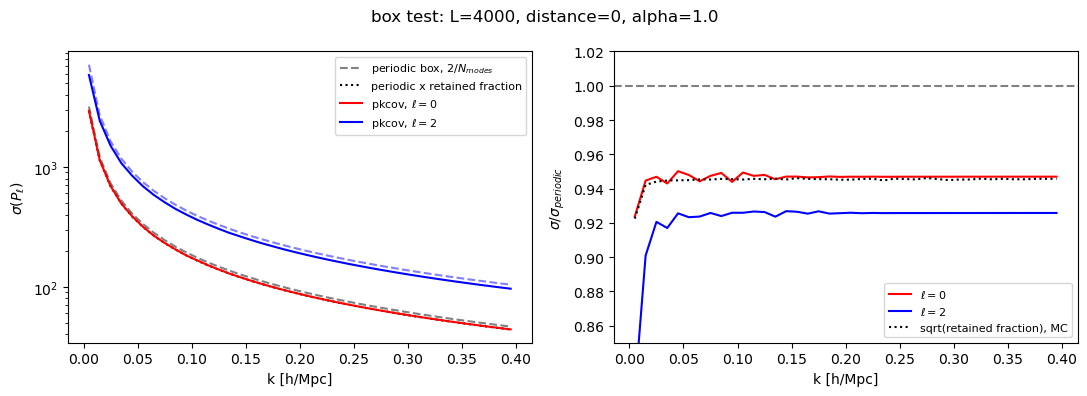

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(kc, np.sqrt(analytic[(0, 0)]), c='gray', ls='dashed', label='periodic box, $2/N_{modes}$')
ax[0].semilogy(kc, np.sqrt(analytic[(0, 0)] * retained), c='k', ls='dotted', label='periodic x retained fraction')
ax[0].semilogy(kc, np.sqrt(np.diag(block[(0, 0)])), c='red', label='pkcov, $\\ell=0$')
ax[0].semilogy(kc, np.sqrt(np.diag(block[(2, 2)])), c='blue', label='pkcov, $\\ell=2$')
ax[0].semilogy(kc, np.sqrt(analytic[(2, 2)]), c='blue', ls='dashed', alpha=0.5)
ax[0].set_xlabel('k [h/Mpc]'); ax[0].set_ylabel(r'$\sigma(P_\ell)$'); ax[0].legend(fontsize=8)
ax[1].plot(kc, np.sqrt(np.diag(block[(0, 0)]) / analytic[(0, 0)]), c='red', label=r'$\ell=0$')
ax[1].plot(kc, np.sqrt(np.diag(block[(2, 2)]) / analytic[(2, 2)]), c='blue', label=r'$\ell=2$')
ax[1].plot(kc, np.sqrt(retained), c='k', ls='dotted', label='sqrt(retained fraction), MC')
ax[1].axhline(1, c='gray', ls='dashed')
ax[1].set_ylim(0.85, 1.02); ax[1].set_xlabel('k [h/Mpc]'); ax[1].set_ylabel(r'$\sigma / \sigma_{periodic}$'); ax[1].legend(fontsize=8)
fig.suptitle(f'box test: L={boxsize:.0f}, distance={distance:.0f}, alpha={alpha}')
fig.tight_layout()
# fig.savefig(f'box_test_d{int(distance)}.png', dpi=120)
# print(f"saved box_test_d{int(distance)}.png")
